### **Importing the required Python libraries**




In [ ]:
#Importing the required libraries needed for the Phising Email Dectector
from google.colab import drive #Calling the drive within Google Drive which the CSV files are stored
import os
import pandas as pd            #Used for reading the Phising Email Dataset
import re                      #Used for regular expressions and handling cleaning of the text

#Utilized the nltk library to handle the tokenization and stemming of the email text in the CSV
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords   # Handles the removing the stopwords
from nltk.stem import PorterStemmer #Handles stemming the words in the dataset to their root words


#Utilized the Count Vectorizer to vectorize the Phising Email Data
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Preprocessed function created which handles the preprocessing of the Phising Email CSV Dataset
#Parameter: Takes in the filepath of where the CSV Dataset is stored

file_path = ('/content/drive/MyDrive/Phising_Emails_CSVs')
def DataSet(file_path) :

  #Looping through the directory to acquire the file Datasets which have .CSV extensions
  for filename in os.listdir(file_path) :
    #If the file ends with .CSV
    if filename.endswith(".csv") :
      #Find the files within the file path that contain the .CSV extension
      csv_file_path = os.path.join(file_path, filename)
      #Read the Dataset using pandas read command
      df = pd.read_csv(csv_file_path, encoding='mac_roman')

      #Preforming Binary Classification by labeling the data in the dataset as either 0 for legitamite or 1 for phising
      df['Label'] = df['Email Type'].apply(lambda x: 1 if x == "Phishing Email" else 0)

      #Filling in empty email text cells within the CSV file to ensure they are not NaN
      df['Email Text'] = df['Email Text'].fillna(' ')

      return df
#Calling the function
df = DataSet(file_path)
#Printing out the first 5 rows of the dataset to ensure labeling has been applied
df.head()

,Unnamed: 0,Email Text,Email Type,Label
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,2,re : equistar deal tickets are you still avail...,Safe Email,0
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1


Refrences

[Read in all CSV files from a directory in Python (Stack Overflow)](https://stackoverflow.com/questions/33503993/read-in-all-csv-files-from-a-directory-using-python)

[Pandas Library W3Schools](https://www.w3schools.com/python/pandas/pandas_intro.asp)

[Pandas Cleaning Empty Cells](https://www.w3schools.com/python/pandas/pandas_cleaning_empty_cells.asp)



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18650 non-null  object
 2   Email Type  18650 non-null  object
 3   Label       18650 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 582.9+ KB


In [ ]:
df.columns

Index(['Unnamed: 0', 'Email Text', 'Email Type', 'Label'], dtype='object')

In [ ]:
def textCleaning(text) :


  #Coverting the text to lowercase
  text = text.lower()

  #Removing the punctuation in the email text
  text = re.sub(r'[^\w\s]', '', text)

  #Removing the HTML Tags within the email text
  text = re.sub(r'<.*?>', '', text)

  #Removing the URL tags within the email text
  text = re.sub(r'http\S+', '', text)



  #removing the stopwords within the email text
  stopwords_set = set(stopwords.words('english'))

  #Tokenisation which using the split function to split the words
  tokens = text.split()
  tokens = [word for word in tokens if word not in stopwords_set]


  #Stemmig the words to their root form
  ps = PorterStemmer()
  text = [ps.stem(word) for word in tokens]
  text = ' '.join(text)

  #returning it and displaying it
  return text

df['Clean_Text'] = df['Email Text'].apply(textCleaning)
df.head()

,Unnamed: 0,Email Text,Email Type,Label,Clean_Text
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,6 1100 disc uniformitarian 1086 sex lang dick ...
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0,side galicismo galicismo spanish term name imp...
2,2,re : equistar deal tickets are you still avail...,Safe Email,0,equistar deal ticket still avail assist robert...
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1,hello hot lil horni toy one dream open mind pe...
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1,softwar incred low price 86 lower draperi seve...


In [ ]:
df['Clean_Text'].iloc[0]

'6 1100 disc uniformitarian 1086 sex lang dick hudson observ us use aughter voc thoughtprovok sure fair attribut son treat like senior rel one thing nt normal use brother way aughter hard imagin natur class compris senior rel exclud brother anoth seem differ imagin distinct seem senior rel term use wider varieti context e g call distanc get someon attent henc begin utter wherea seem natur utter like ye son hand son one like son son help although perhap latter one complet imposs alexi mr'

**Refrences**

[NLP Guide: Stemming and Lemmitization](https://medium.com/@martinthetechie/nlp-guide-stemming-lemmatization-426f7ee2dbd6)

[re-Regular Expression Operations](https://docs.python.org/3/library/re.html)

[Removing Punctuation from String using re library](https://www.geeksforgeeks.org/python/python-remove-punctuation-from-string/)

[Text Data Preprocessing Made Easy: Steps to Clean Text Data Using Python](https://medium.com/@pawan329/text-data-preprocessing-made-easy-steps-to-clean-text-data-using-python-81a138a0e0e3)


In [ ]:
# Initialize the CountVectorizer
vectorizer = CountVectorizer(max_features = 10000, token_pattern=r'\b[a-zA-Z]{2,}\b')

# Fit and transform the 'Email Text' data
X = vectorizer.fit_transform(df['Clean_Text']).toarray()

# Create a new DataFrame with the vectorized data and the correct feature names
df_vectorized = pd.DataFrame(X, columns=vectorizer.get_feature_names_out())

# Display the head of the new vectorized DataFrame
display(df_vectorized.head(20))

drive.mount('/content/drive')

# Save CountVectorizer model to the Google Drive
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/countvectorizer.pkl'
import pickle # Import pickle to save the vectorizer
with open(model_path, 'wb') as file:
    pickle.dump(vectorizer, file) # Corrected variable name from countvectorizer to vectorizer

print(f"Vectorizer saved to {model_path}")

,aa,aaa,aaai,aaal,aac,aachen,aactiv,aaron,ab,abacha,...,zonedubai,zoom,zu,zum,zur,zurich,zwart,zwicki,zwischen,zyban
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Vectorizer saved to /content/drive/My Drive/Phishing_Email_ML_Models/countvectorizer.pkl


# **Refrences**
[Using Count Vectorizer to extract features from text](https://www.geeksforgeeks.org/nlp/using-countvectorizer-to-extracting-features-from-text/)

[sklearn Count Vectorizer token_pattern](https://datascience.stackexchange.com/questions/29352/sklearn-countvectorizer-token-pattern-skip-token-if-pattern-match)

Logistic Regression Accuracy: 96.38%
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2278
           1       0.93      0.98      0.95      1452

    accuracy                           0.96      3730
   macro avg       0.96      0.97      0.96      3730
weighted avg       0.96      0.96      0.96      3730

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/My Drive/Phishing_Email_ML_Models/lg_model.pkl


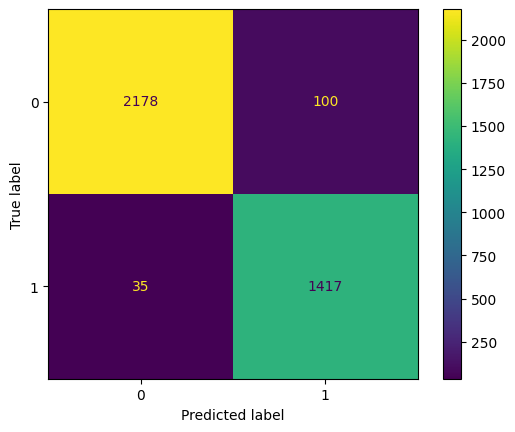

In [ ]:
#Implementing the code to train the models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
import pickle
import os

#Preforming the 80/20 training and testing split
X_train, X_test, y_train, y_test = train_test_split(df_vectorized, df['Label'], test_size=0.2)

#Intializing the Logistic Regression instance
lg_model = LogisticRegression()
#Training the Logistic Regression model on 80% of the data
lg_model.fit(X_train, y_train)
#Testing the Logisitic Regression model on the remaining 20% of the data
lg_pred = lg_model.predict(X_test)
#Acquiring the accuracy score of the Logisitic Regression model
lg_accuracy = accuracy_score(y_test, lg_pred)
#Printing out the Accuaracy score
print(f"Logistic Regression Accuracy: {lg_accuracy:.2%}")
#Printing out the Classification Report
print(classification_report(y_test, lg_pred))
#Displaying the Confusion Matrix
print(ConfusionMatrixDisplay.from_predictions(y_test, lg_pred))

drive.mount('/content/drive')

# Save Logistic Regression model
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/lg_model.pkl'
os.makedirs(os.path.dirname(model_path), exist_ok=True) # Create directory if it doesn't exist
with open(model_path, 'wb') as file:
    pickle.dump(lg_model, file)

print(f"Model saved to {model_path}")

Random Forest Accuracy: 96.03%
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2278
           1       0.94      0.96      0.95      1452

    accuracy                           0.96      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/My Drive/Phishing_Email_ML_Models/random_forest_model.pkl


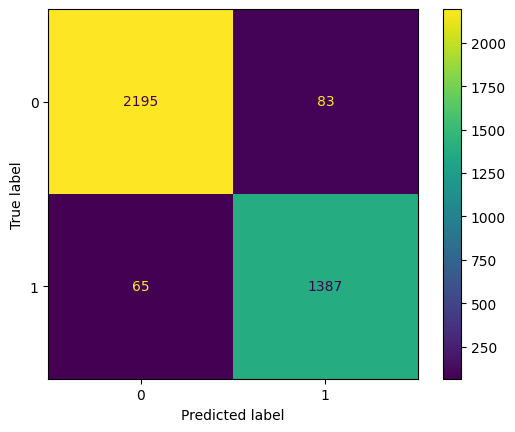

In [ ]:
#Intializing the Random Forest Classifier Instance
random_forest_model = RandomForestClassifier()
#Training the model using 80% of the dataset
random_forest_model.fit(X_train, y_train)
# Testing the model on the remaining 20% of the dataset
random_forest_pred = random_forest_model.predict(X_test)
#Acquiring the accuracy score of the ML model
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
#Printing out the Accuracy score result to the terminal
print(f"Random Forest Accuracy: {random_forest_accuracy:.2%}")
#Printing out the classification report of the ML model
print(classification_report(y_test, random_forest_pred))
#Displaying the Confusion matrix of the ML model
print(ConfusionMatrixDisplay.from_predictions(y_test, random_forest_pred))


drive.mount('/content/drive')

# Save Random Forest model to a folder within Google Drive Directory
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/random_forest_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(random_forest_model, file)

print(f"Model saved to {model_path}")

MultinomialNB Accuracy: 92.23%
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      2278
           1       0.86      0.95      0.91      1452

    accuracy                           0.92      3730
   macro avg       0.91      0.93      0.92      3730
weighted avg       0.93      0.92      0.92      3730

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/My Drive/Phishing_Email_ML_Models/mNB_model.pkl


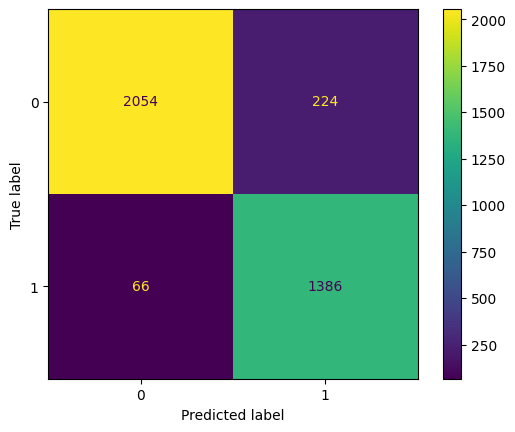

In [ ]:
#Intializing the Multinomial Bayes model
MultinomialNB_model = MultinomialNB()
#Training the ML model on 80% of the dataset
MultinomialNB_model.fit(X_train, y_train)
#Testing the ML model on the remaining 20% of the dataset
MultinomialNB_pred = MultinomialNB_model.predict(X_test)
#Acquriing the accuracy score of the ML model
MultinomialNB_accuracy = accuracy_score(y_test, MultinomialNB_pred)
#Printing the overall prediction accuracy of the ML model
print(f"MultinomialNB Accuracy: {MultinomialNB_accuracy:.2%}")
#Printing out the classification report of the ML model
print(classification_report(y_test, MultinomialNB_pred))
#Displaying the Confusion Matrix of the ML model
print(ConfusionMatrixDisplay.from_predictions(y_test, MultinomialNB_pred))

drive.mount('/content/drive')

# Save Multinomial Naive Bayes model to a folder within my Google Drive Directory
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/mNB_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(lg_model, file)

print(f"Model saved to {model_path}")

SVC Accuracy: 63.11%
              precision    recall  f1-score   support

           0       0.62      1.00      0.77      2278
           1       0.95      0.06      0.10      1452

    accuracy                           0.63      3730
   macro avg       0.79      0.53      0.44      3730
weighted avg       0.75      0.63      0.51      3730

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/My Drive/Phishing_Email_ML_Models/svc_model.pkl


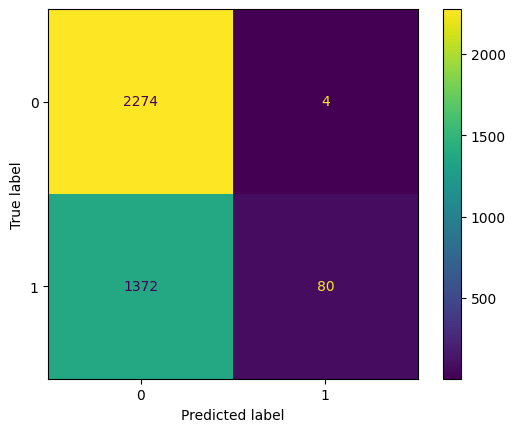

In [ ]:
#Intialzing the SVM model
svc_model = SVC()
#Training the ML model on 80% of the dataset
svc_model.fit(X_train, y_train)
#Testing the ML model on the remaining 20% of the dataset
svc_pred = svc_model.predict(X_test)
#Acquring the overall accuracy of the ML model
svc_accuracy = accuracy_score(y_test, svc_pred)
#Printing out the SVM overall accuracy to the console
print(f"SVC Accuracy: {svc_accuracy:.2%}")
#Printing out the classification report of the SVM model
print(classification_report(y_test, svc_pred))
#Displaying the Confusion Matrix of the SVM model
print(ConfusionMatrixDisplay.from_predictions(y_test, svc_pred))

drive.mount('/content/drive')

# Save SVM model to a folder within the Google Drive directory
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/svc_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(svc_model, file)

print(f"Model saved to {model_path}")

XGBoost Accuracy: 95.74%
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2278
           1       0.93      0.96      0.95      1452

    accuracy                           0.96      3730
   macro avg       0.95      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730

Model saved to /content/drive/My Drive/Phishing_Email_ML_Models/xgb_model.pkl


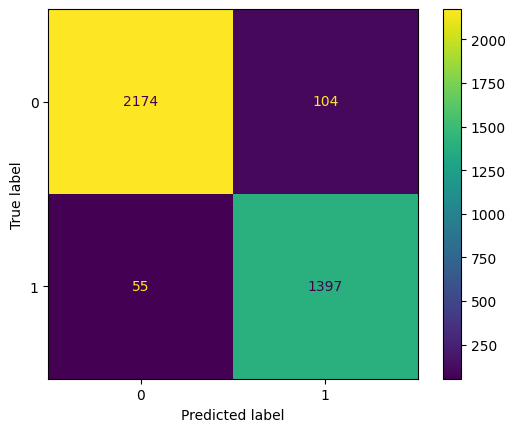

In [ ]:
#Initlaized the XGBoost Algorithm Classifer
xgb_model = XGBClassifier()
#Training the XGBoost model on 80% of the dataset
xgb_model.fit(X_train, y_train)
#Testing the XGBoost model on the remaining 20% of the dataset
xgb_pred = xgb_model.predict(X_test)
#Acquiring the accuracy score of the XGBoost model
xgb_accuracy = accuracy_score(y_test, xgb_pred)

#Printing the XGBoost accuracy to the console
print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")
#Printing the Classification Report of the XGBoost to the console
print(classification_report(y_test, xgb_pred))
#Displaying the Confusion Matrix of the XGBoost Model
print(ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred))

# Save XGBoost model to a folder within the Google Drive Directory
model_path = '/content/drive/My Drive/Phishing_Email_ML_Models/xgb_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(xgb_model, file)

print(f"Model saved to {model_path}")


In [ ]:
#Implementing the ROC AUC-Curve to compare all four machine learning models
from sklearn.metrics import roc_curve, auc

# Calculating the ROC curve and AUC for the Logistic Regression Model
lg_fpr, lg_tpr, _ = roc_curve(y_test, lg_pred)
lg_auc = auc(lg_fpr, lg_tpr)
# Calculating the ROC curve and AUC for the Random Forest Model
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_pred)
random_forest_auc = auc(random_forest_fpr, random_forest_tpr)
# Calculating the ROC curve and AUC for the Multinomial Bayes Model
MultinomialNB_fpr, MultinomialNB_tpr, _ = roc_curve(y_test, MultinomialNB_pred)
MultinomialNB_auc = auc(MultinomialNB_fpr, MultinomialNB_tpr)
# Calculating the ROC curve and AUC for the SVM Model
svc_fpr, svc_tpr, _ = roc_curve(y_test, svc_pred)
svc_auc = auc(svc_fpr, svc_tpr)
# Calculating the ROC curve and AUC for the XGBoost Model
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred)
xgb_auc = auc(xgb_fpr, xgb_tpr)

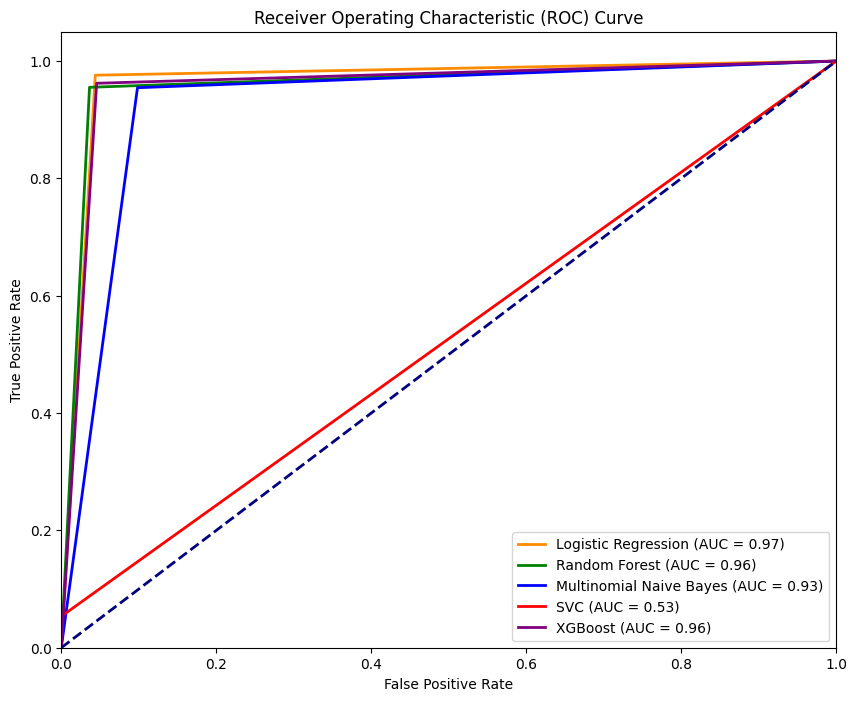

In [ ]:
# Plotting the ROC AUC curves on one singular plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(lg_fpr, lg_tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {lg_auc:.2f})')
plt.plot(random_forest_fpr, random_forest_tpr, color='green', lw=2, label=f'Random Forest (AUC = {random_forest_auc:.2f})')
plt.plot(MultinomialNB_fpr, MultinomialNB_tpr, color='blue', lw=2, label=f'Multinomial Naive Bayes (AUC = {MultinomialNB_auc:.2f})')
plt.plot(svc_fpr, svc_tpr, color='red', lw=2, label=f'SVC (AUC = {svc_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, color='purple', lw=2, label=f'XGBoost (AUC = {xgb_auc:.2f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Refrences

[Machine Learning - AUC - ROC Curve](https://www.w3schools.com/python/python_ml_auc_roc.asp)

[How to Plot ROC Curve (Stack Overflow)](https://stackoverflow.com/questions/25009284/how-to-plot-roc-curve-in-python)